# Imbalanced Model Testing without Class Weights

In [53]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [54]:
df = pd.read_csv("logs/WednesdayTraffic_cleaned.csv")

In [55]:
X = df.drop("Label", axis=1)
y = df["Label"]

print(X.shape)
print(y.shape)

X.dtypes

(1031018, 79)
(1031018,)


Dst Port           int64
Protocol           int64
Timestamp            str
Flow Duration      int64
Tot Fwd Pkts       int64
                  ...   
Active Min         int64
Idle Mean        float64
Idle Std         float64
Idle Max           int64
Idle Min           int64
Length: 79, dtype: object

In [56]:
df = df.drop("Timestamp", axis=1)
df = df.drop_duplicates()

X = df.drop("Label", axis=1)
y = df["Label"]



In [57]:
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

print("\nTraining label distribution:")
print(y_train.value_counts())

print("\nTraining label proportions:")
print(y_train.value_counts(normalize=True))

print("\nTest label distribution:")
print(y_test.value_counts())

print("\nTest label proportions:")
print(y_test.value_counts(normalize=True))

Training set: (449124, 78)
Test set: (112281, 78)

Training label distribution:
Label
0    288651
1    160473
Name: count, dtype: int64

Training label proportions:
Label
0    0.642698
1    0.357302
Name: proportion, dtype: float64

Test label distribution:
Label
0    72163
1    40118
Name: count, dtype: int64

Test label proportions:
Label
0    0.6427
1    0.3573
Name: proportion, dtype: float64


In [58]:
# Keep the original split
X_train_imb = X_train.copy()
y_train_imb = y_train.copy()

print("Imbalanced training distribution:")
print(y_train_imb.value_counts())

Imbalanced training distribution:
Label
0    288651
1    160473
Name: count, dtype: int64


# Logistic Regression (Unscaled Pipeline)

In [59]:
log_pipe_unscaled = Pipeline([
    ("model", LogisticRegression(max_iter=1000))
])

log_pipe_unscaled.fit(X_train_imb, y_train_imb)

log_pred_unscaled = log_pipe_unscaled.predict(X_test)

print("Logistic Regression (Unscaled) Results")
print(classification_report(y_test, log_pred_unscaled))

Logistic Regression (Unscaled) Results
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     72163
           1       1.00      1.00      1.00     40118

    accuracy                           1.00    112281
   macro avg       1.00      1.00      1.00    112281
weighted avg       1.00      1.00      1.00    112281



In [60]:
train_pred_unscaled = log_pipe_unscaled.predict(X_train_imb)
print("Training performance - Logistic Regression (Unscaled)")
print(classification_report(y_train_imb, train_pred_unscaled))

y_pred_unscaled = log_pipe_unscaled.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_unscaled))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_unscaled))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_unscaled))

Training performance - Logistic Regression (Unscaled)
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    288651
           1       1.00      1.00      1.00    160473

    accuracy                           1.00    449124
   macro avg       1.00      1.00      1.00    449124
weighted avg       1.00      1.00      1.00    449124

Accuracy: 0.9999821875473144

Confusion Matrix:
[[72161     2]
 [    0 40118]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     72163
           1       1.00      1.00      1.00     40118

    accuracy                           1.00    112281
   macro avg       1.00      1.00      1.00    112281
weighted avg       1.00      1.00      1.00    112281



# Logistic Regression (Scaled Pipeline)

In [61]:
log_pipe_scaled = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

log_pipe_scaled.fit(X_train_imb, y_train_imb)

log_pred_scaled = log_pipe_scaled.predict(X_test)

print("Logistic Regression (Scaled) Results")
print(classification_report(y_test, log_pred_scaled))

Logistic Regression (Scaled) Results
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     72163
           1       1.00      1.00      1.00     40118

    accuracy                           1.00    112281
   macro avg       1.00      1.00      1.00    112281
weighted avg       1.00      1.00      1.00    112281



In [62]:
train_pred_scaled = log_pipe_scaled.predict(X_train_imb)
print("Training performance - Logistic Regression (Scaled)")
print(classification_report(y_train_imb, train_pred_scaled))

y_pred_scaled = log_pipe_scaled.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_scaled))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_scaled))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_scaled))

Training performance - Logistic Regression (Scaled)
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    288651
           1       1.00      1.00      1.00    160473

    accuracy                           1.00    449124
   macro avg       1.00      1.00      1.00    449124
weighted avg       1.00      1.00      1.00    449124

Accuracy: 0.9999821875473144

Confusion Matrix:
[[72161     2]
 [    0 40118]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     72163
           1       1.00      1.00      1.00     40118

    accuracy                           1.00    112281
   macro avg       1.00      1.00      1.00    112281
weighted avg       1.00      1.00      1.00    112281



# Decision Tree Model

In [63]:
tree_pipe = Pipeline([
    ("model", DecisionTreeClassifier(
        max_depth=20,
        min_samples_split=10,
        random_state=42
    ))
])

tree_pipe.fit(X_train_imb, y_train_imb)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If fl

In [64]:
tree_pred = tree_pipe.predict(X_test)

print("Accuracy:", accuracy_score(y_test, tree_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, tree_pred))

print("\nClassification Report:")
print(classification_report(y_test, tree_pred))

tree_model = tree_pipe.named_steps["model"]
importance = pd.Series(tree_model.feature_importances_, index=X_train_imb.columns)
print(importance.sort_values(ascending=False).head(10))

Accuracy: 0.9999910937736571

Confusion Matrix:
[[72162     1]
 [    0 40118]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     72163
           1       1.00      1.00      1.00     40118

    accuracy                           1.00    112281
   macro avg       1.00      1.00      1.00    112281
weighted avg       1.00      1.00      1.00    112281

Dst Port            0.986584
Fwd Pkts/s          0.013364
Fwd Seg Size Min    0.000039
Flow IAT Max        0.000013
Flow Duration       0.000000
Protocol            0.000000
TotLen Bwd Pkts     0.000000
Fwd Pkt Len Max     0.000000
Fwd Pkt Len Min     0.000000
Fwd Pkt Len Mean    0.000000
dtype: float64


In [65]:
# Just to test if there is any data leakage / overfitting
train_pred = tree_pipe.predict(X_train_imb)

print(classification_report(y_train_imb, train_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    288651
           1       1.00      1.00      1.00    160473

    accuracy                           1.00    449124
   macro avg       1.00      1.00      1.00    449124
weighted avg       1.00      1.00      1.00    449124



# Random Forest

In [66]:
rf_pipe = Pipeline([
    ("model", RandomForestClassifier(
        n_estimators=200,
        max_depth=20,
        random_state=42,
        n_jobs=-1
    ))
])

rf_pipe.fit(X_train_imb, y_train_imb)

rf_pred = rf_pipe.predict(X_test)

print("Accuracy:", accuracy_score(y_test, rf_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, rf_pred))
print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

Accuracy: 1.0

Confusion Matrix:
[[72163     0]
 [    0 40118]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     72163
           1       1.00      1.00      1.00     40118

    accuracy                           1.00    112281
   macro avg       1.00      1.00      1.00    112281
weighted avg       1.00      1.00      1.00    112281



Dst Port             0.138820
Fwd Pkt Len Max      0.101116
Fwd Pkt Len Mean     0.092612
Fwd Pkt Len Std      0.073168
Fwd Seg Size Avg     0.071419
TotLen Fwd Pkts      0.064781
Init Bwd Win Byts    0.064053
Subflow Fwd Pkts     0.056010
Tot Fwd Pkts         0.055743
Fwd Header Len       0.055568
dtype: float64


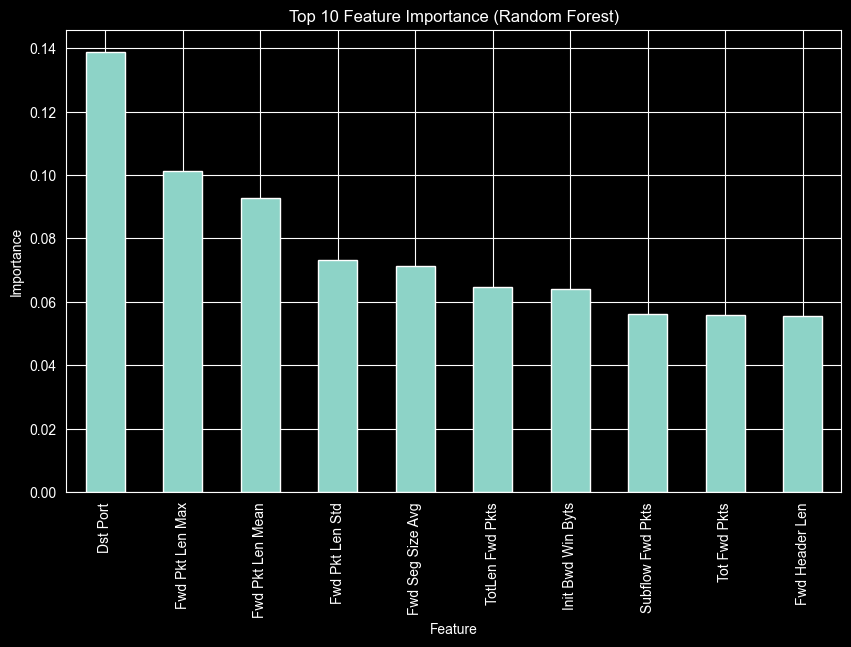

In [67]:
rf_model = rf_pipe.named_steps["model"]

importance = pd.Series(rf_model.feature_importances_, index=X_train_imb.columns)
print(importance.sort_values(ascending=False).head(10))

importance = importance.sort_values(ascending=False)

plt.figure(figsize=(10, 6))
importance.head(10).plot(kind="bar")
plt.title("Top 10 Feature Importance (Random Forest)")
plt.ylabel("Importance")
plt.xlabel("Feature")
plt.show()

In [68]:
scores = cross_val_score(
    rf_pipe,
    X_train_imb,
    y_train_imb,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

print("Cross-validation scores:", scores)
print("Average F1 score:", np.mean(scores))

Cross-validation scores: [1.         1.         0.99998442 1.         1.        ]
Average F1 score: 0.999996884298422


Lets do an interesting experiment again, where we test performance to ensure there is no leakage. 
If we shuffle the labels and the model performance collapses, that supports the idea that the pipeline is learning real structure instead of memorizing labels.

In [69]:
y_shuffled = np.random.permutation(y_train_imb)

rf_shuffle_pipe = Pipeline([
    ("model", RandomForestClassifier(
        n_estimators=200,
        max_depth=20,
        random_state=42,
        n_jobs=-1
    ))
])

rf_shuffle_pipe.fit(X_train_imb, y_shuffled)

shuffle_pred = rf_shuffle_pipe.predict(X_test)

print("Accuracy:", accuracy_score(y_test, shuffle_pred))
print(classification_report(y_test, shuffle_pred))

Accuracy: 0.6424150123351234
              precision    recall  f1-score   support

           0       0.64      1.00      0.78     72163
           1       0.38      0.00      0.00     40118

    accuracy                           0.64    112281
   macro avg       0.51      0.50      0.39    112281
weighted avg       0.55      0.64      0.50    112281



In [70]:
# If needed, install once:
# !pip install imbalanced-learn

from imblearn.ensemble import BalancedRandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, balanced_accuracy_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Percentages of the training set to test
fractions = [0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 1.00]

# Repeat each experiment a few times for stability
n_repeats = 5

results = []

for frac in fractions:
    for seed in range(n_repeats):

        # Use the full training set for 100%
        if frac == 1.0:
            X_sub = X_train_imb.copy()
            y_sub = y_train_imb.copy()
        else:
            X_sub, _, y_sub, _ = train_test_split(
                X_train_imb,
                y_train_imb,
                train_size=frac,
                stratify=y_train_imb,
                random_state=42 + seed
            )

        brf = BalancedRandomForestClassifier(
            n_estimators=200,
            max_depth=20,
            random_state=42 + seed,
            n_jobs=-1
        )

        brf.fit(X_sub, y_sub)
        y_pred = brf.predict(X_test)

        results.append({
            "train_fraction": frac,
            "train_percent": int(frac * 100),
            "n_train_rows": len(X_sub),
            "repeat": seed + 1,
            "accuracy": accuracy_score(y_test, y_pred),
            "f1": f1_score(y_test, y_pred),
            "balanced_accuracy": balanced_accuracy_score(y_test, y_pred)
        })

results_df = pd.DataFrame(results)

summary_df = (
    results_df
    .groupby(["train_fraction", "train_percent"], as_index=False)
    .agg(
        n_train_rows_mean=("n_train_rows", "mean"),
        accuracy_mean=("accuracy", "mean"),
        accuracy_std=("accuracy", "std"),
        f1_mean=("f1", "mean"),
        f1_std=("f1", "std"),
        balanced_acc_mean=("balanced_accuracy", "mean"),
        balanced_acc_std=("balanced_accuracy", "std")
    )
)

print(summary_df.round(6))

   train_fraction  train_percent  n_train_rows_mean  accuracy_mean  \
0            0.01              1             4491.0       0.999585   
1            0.05              5            22456.0       0.999874   
2            0.10             10            44912.0       0.999918   
3            0.25             25           112281.0       0.999954   
4            0.50             50           224562.0       0.999977   
5            0.75             75           336843.0       0.999980   
6            1.00            100           449124.0       0.999982   

   accuracy_std   f1_mean    f1_std  balanced_acc_mean  balanced_acc_std  
0      0.000165  0.999420  0.000231           0.999677          0.000129  
1      0.000109  0.999823  0.000152           0.999902          0.000085  
2      0.000026  0.999885  0.000037           0.999936          0.000020  
3      0.000010  0.999935  0.000014           0.999964          0.000008  
4      0.000005  0.999968  0.000007           0.999982          

In [71]:
summary_df_rounded = summary_df.copy()
for col in summary_df_rounded.columns:
    if "mean" in col or "std" in col:
        summary_df_rounded[col] = summary_df_rounded[col].round(6)

summary_df_rounded

,train_fraction,train_percent,n_train_rows_mean,accuracy_mean,accuracy_std,f1_mean,f1_std,balanced_acc_mean,balanced_acc_std
0,0.01,1,4491.0,0.999585,0.000165,0.999420,0.000231,0.999677,0.000129
1,0.05,5,22456.0,0.999874,0.000109,0.999823,0.000152,0.999902,0.000085
2,0.10,10,44912.0,0.999918,0.000026,0.999885,0.000037,0.999936,0.000020
3,0.25,25,112281.0,0.999954,0.000010,0.999935,0.000014,0.999964,0.000008
4,0.50,50,224562.0,0.999977,0.000005,0.999968,0.000007,0.999982,0.000004
5,0.75,75,336843.0,0.999980,0.000007,0.999973,0.000010,0.999985,0.000006
6,1.00,100,449124.0,0.999982,0.000000,0.999975,0.000000,0.999986,0.000000
